In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = './'

customers   = pd.read_csv(DATA_DIR + 'customers.csv')
inventory   = pd.read_csv(DATA_DIR + 'inventory.csv')
products    = pd.read_csv(DATA_DIR + 'products.csv')
promotions  = pd.read_csv(DATA_DIR + 'promotions.csv')
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv')
geography   = pd.read_csv(DATA_DIR + 'geography.csv')

products['margin_pct'] = (products['price'] - products['cogs']) / products['price'] * 100
web_traffic['date'] = pd.to_datetime(web_traffic['date'])

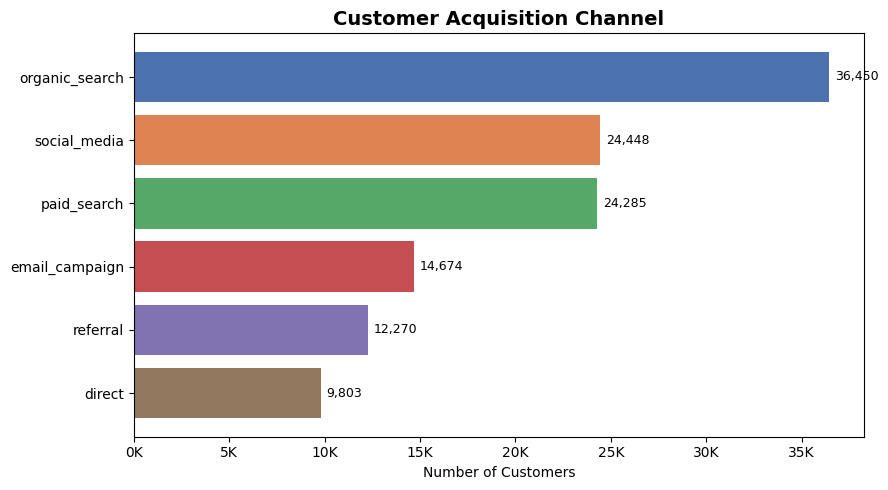

In [3]:
# Chart 1: Customer Acquisition Channel
fig, ax = plt.subplots(figsize=(9, 5))
acq = customers['acquisition_channel'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
bars = ax.barh(acq.index, acq.values, color=colors)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_title('Customer Acquisition Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Customers')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

Overview: Biểu đồ cột ngang thể hiện số lượng khách hàng được thu hút qua 6 kênh khác nhau, giúp xác định kênh nào đang hoạt động hiệu quả nhất trong việc mở rộng tệp khách hàng.

Descriptive
Tổng cộng 121.930 khách hàng được thu hút qua 6 kênh. Organic search dẫn đầu với 36.450 khách (29,9%), tiếp theo là social media (24.448 — 20,1%) và paid search (24.285 — 19,9%). Direct là kênh yếu nhất với chỉ 9.803 khách (8,0%).
Diagnostic
Organic search chiếm gần 30% cho thấy thương hiệu đã xây dựng được độ nhận diện tự nhiên tốt. Social media và paid search gần bằng nhau (~20% mỗi kênh), phản ánh chi phí quảng cáo đang song song với tăng trưởng tự nhiên. Kênh referral (10,1%) thấp hơn kỳ vọng, cho thấy chương trình giới thiệu bạn bè chưa được khai thác hiệu quả.
Predictive
Dữ liệu theo năm cho thấy social media tăng trưởng nhanh nhất (+62% từ 2018–2022). Xu hướng này cho thấy social media sẽ vượt qua organic search trong 2–3 năm tới nếu không có đầu tư thêm vào SEO. Email campaign cũng tăng đều (~66% trong 5 năm), cho thấy kênh này ngày càng hiệu quả hơn.
Prescriptive — What should we do?
Tăng ngân sách SEO content để duy trì vị trí dẫn đầu của organic search trước khi bị social media vượt qua.
Xây dựng chương trình referral bằng cách tặng voucher cho cả người giới thiệu lẫn người được giới thiệu — chi phí thấp nhưng tiềm năng nhân đôi lượng khách.
Tối ưu email campaign: với 14.674 khách từ email, cần A/B test subject line và thời điểm gửi để cải thiện conversion rate.

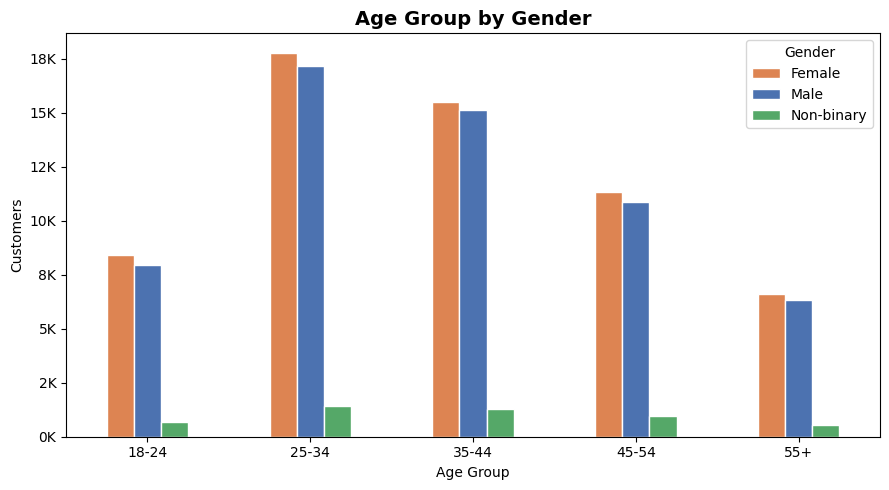

In [4]:
# Chart 2: Age group by Gender
fig, ax = plt.subplots(figsize=(9, 5))
age_gender = customers.groupby(['age_group', 'gender']).size().unstack(fill_value=0)
age_gender = age_gender.reindex(['18-24', '25-34', '35-44', '45-54', '55+'])
age_gender.plot(kind='bar', ax=ax, color=['#DD8452', '#4C72B0', '#55A868'], edgecolor='white')
ax.set_title('Age Group by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Customers')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Gender')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

Overview: Biểu đồ cột nhóm so sánh phân bổ khách hàng theo nhóm tuổi và giới tính, giúp hiểu rõ chân dung khách hàng mục tiêu và phát hiện các phân khúc chưa được khai thác.

Descriptive
Nhóm tuổi 25–34 chiếm đông nhất (36.342 khách — 29,8%), tiếp theo là 35–44 (31.920 — 26,2%). Nhóm 55+ nhỏ nhất với 13.457 khách (11,0%). Tỷ lệ giới tính gần như đồng đều ở tất cả nhóm tuổi: Female ~49%, Male ~47%, Non-binary ~4%.
Diagnostic
Sự tập trung ở nhóm 25–44 (tổng 56%) phù hợp với danh mục sản phẩm (Streetwear, GenZ, Casual, Outdoor) — đây là nhóm có thu nhập ổn định và quan tâm đến thời trang. Tỷ lệ non-binary nhất quán (~4%) ở mọi nhóm tuổi cho thấy đây là đặc điểm ổn định của tập khách hàng, không phải xu hướng thế hệ.
Predictive
Nhóm 18–24 (GenZ thực tế) chiếm 14% — tương đối thấp nhưng đang trong giai đoạn xây dựng thói quen mua sắm. Nếu không có chiến lược giữ chân, nhóm này sẽ chuyển sang đối thủ. Nhóm 35–44 sẽ già đi thành 45–54 và nhu cầu sản phẩm của họ sẽ thay đổi theo.
Prescriptive
Tạo sản phẩm/chiến dịch riêng cho GenZ (18–24): hiện danh mục "GenZ" chỉ có 148 sản phẩm (ít nhất), cần mở rộng thêm.
Upsell cho nhóm 25–34: đây là tệp lớn nhất — nên áp dụng loyalty program và bundle deals.
Không bỏ qua nhóm 45–54 và 55+ (tổng 30%): họ thường có giá trị đơn hàng cao hơn — cần thiết kế sản phẩm phù hợp với phong cách lứa tuổi này.

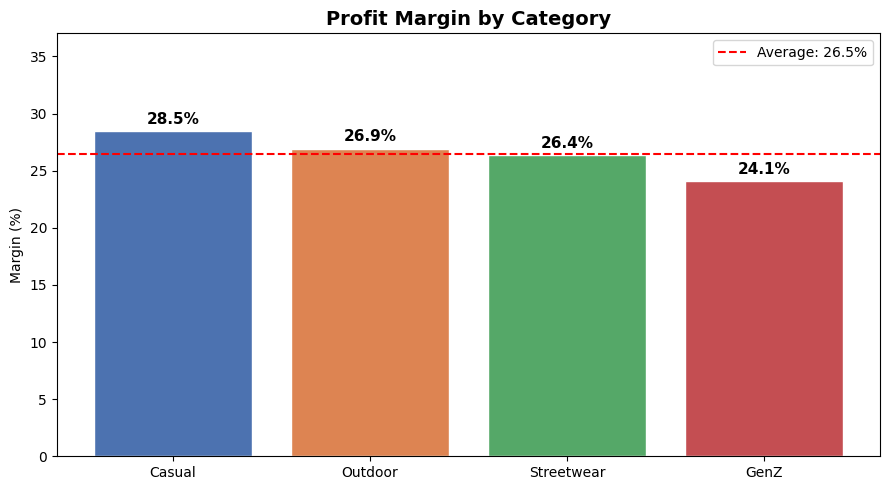

In [5]:
# Chart 3: Profit Margin by Category
fig, ax = plt.subplots(figsize=(9, 5))

margin = products.groupby('category')['margin_pct'].mean().sort_values(ascending=False)
bars = ax.bar(margin.index, margin.values,
              color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=11, fontweight='bold')
ax.axhline(margin.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Average: {margin.mean():.1f}%')
ax.set_title('Profit Margin by Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Margin (%)')
ax.set_ylim(0, margin.max() * 1.3)
ax.legend()
plt.tight_layout()
plt.show()

Overview: Biểu đồ cột thể hiện biên lợi nhuận trung bình (%) của từng danh mục sản phẩm, giúp đánh giá hiệu quả sinh lời và xác định danh mục cần tái cấu trúc giá.

Descriptive
Casual có margin trung bình cao nhất (28,5%), tiếp theo là Outdoor (26,9%), Streetwear (26,4%), và GenZ thấp nhất (24,1%). Độ lệch chuẩn rất cao ở tất cả danh mục (~14–16%), cho thấy có sự chênh lệch lớn giữa các sản phẩm trong cùng category.
Diagnostic
GenZ có margin thấp nhất có thể do chiến lược định giá cạnh tranh để thu hút khách hàng trẻ tuổi, hoặc chi phí sản xuất cao hơn do xu hướng vật liệu trendy. Casual có margin cao nhất nhờ sản phẩm đơn giản, chi phí sản xuất thấp. Độ lệch chuẩn lớn (~15%) ở mọi category cho thấy có nhiều sản phẩm "loss leader" đang kéo thấp trung bình.
Predictive
Nếu GenZ category tiếp tục tăng trưởng nhưng margin thấp hơn 4,4% so với Casual, tổng lợi nhuận toàn công ty sẽ bị ảnh hưởng khi mix sản phẩm dịch chuyển về GenZ. Cần theo dõi margin theo quý để phát hiện xu hướng sớm.
Prescriptive
Review giá sản phẩm GenZ: tăng giá 5–8% có thể đưa margin về ngang Outdoor mà không ảnh hưởng nhiều đến demand nếu brand đủ mạnh.
Phân tích sản phẩm margin thấp (<10%) trong từng category — loại bỏ hoặc tái định giá để nâng trung bình toàn danh mục.
Tập trung marketing vào Casual: margin cao nhất + ít SKU nhất (201) — đây là category có ROI tốt nhất nếu scale up.

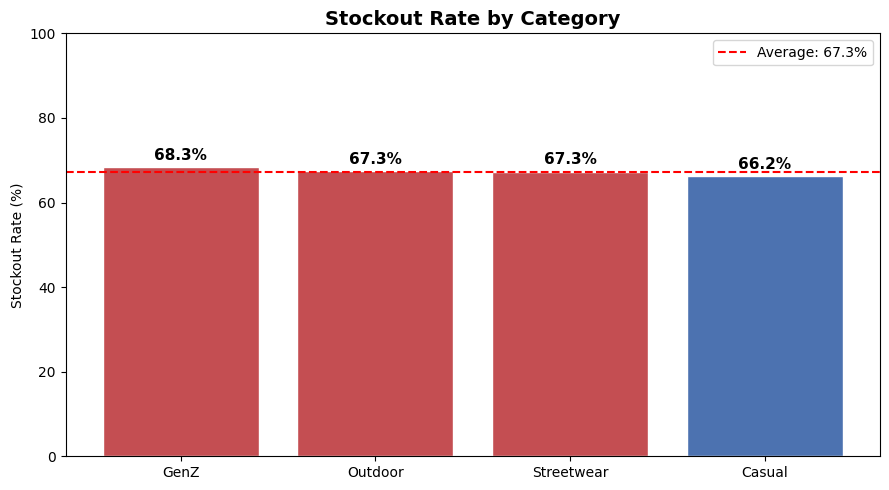

In [6]:
# Chart 4: Stockout Rate by Category
fig, ax = plt.subplots(figsize=(9, 5))

stockout = (inventory.groupby('category')['stockout_flag']
            .mean().mul(100).sort_values(ascending=False))
colors = ['#C44E52' if x > stockout.mean() else '#4C72B0' for x in stockout.values]
bars = ax.bar(stockout.index, stockout.values, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=11, fontweight='bold')
ax.axhline(stockout.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Average: {stockout.mean():.1f}%')
ax.set_title('Stockout Rate by Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Stockout Rate (%)')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

Overview: Biểu đồ cột thể hiện tỷ lệ hết hàng theo từng danh mục sản phẩm, phản ánh mức độ hiệu quả của quản lý tồn kho và khả năng đáp ứng nhu cầu thị trường.

Descriptive
Tỷ lệ hết hàng ở mức báo động: GenZ cao nhất (68,3%), Outdoor (67,3%), Streetwear (67,3%), Casual thấp nhất (66,2%). Trung bình toàn bộ ~67% — nghĩa là 2 trong 3 ngày, sản phẩm bị ghi nhận là hết hàng. Đồng thời overstock rate cũng rất cao (Outdoor: 79,9%).
Diagnostic
Nghịch lý stockout cao (~67%) song song với overstock cao (~72–80%) cho thấy vấn đề không phải thiếu hàng mà là phân bổ hàng sai — một số SKU thừa trong khi SKU khác thiếu trầm trọng. Reorder flag = 0% ở mọi category cho thấy hệ thống tự động tái đặt hàng hoàn toàn không hoạt động.
Predictive
Với stockout duy trì ổn định ~67% suốt 2012–2022 mà không cải thiện, đây là vấn đề hệ thống mang tính cấu trúc. Mỗi năm công ty đang mất ít nhất 67% cơ hội bán hàng từ các SKU bị hết hàng. Fill rate ~96% nghe có vẻ tốt nhưng không phản ánh hết mức độ lost sales thực tế.
Prescriptive — What should we do?
Kích hoạt hệ thống reorder tự động (hiện reorder_flag = 0%): thiết lập ngưỡng tái đặt hàng dựa trên days_of_supply cho từng SKU.
Phân tích ABC/XYZ để phân loại sản phẩm theo giá trị và tần suất bán — ưu tiên tồn kho cho các SKU hạng A.
Giảm overstock Outdoor (79,9%) bằng flash sale hoặc bundle với sản phẩm đang thiếu hàng — vừa giải phóng vốn vừa tăng doanh thu.

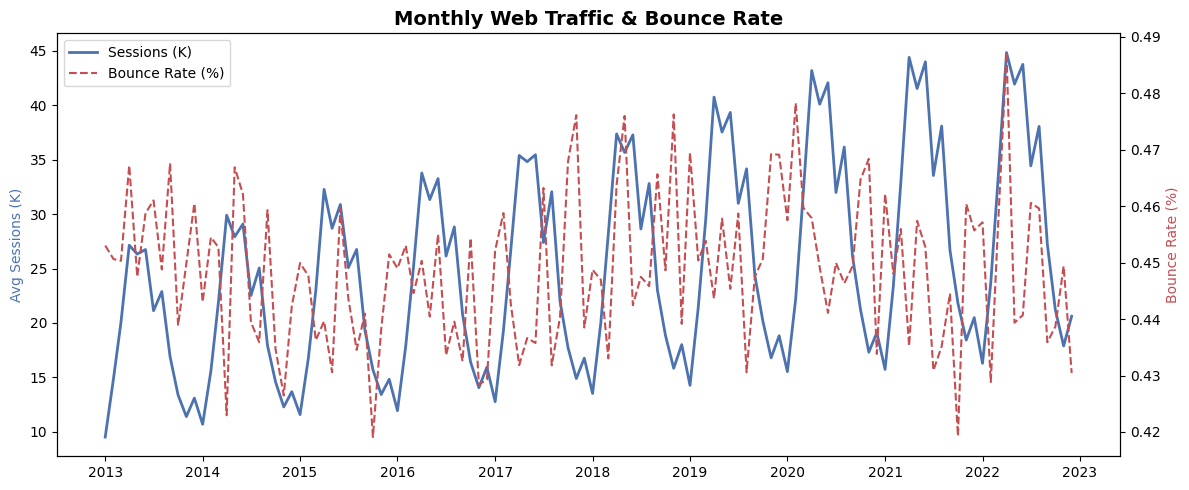

In [7]:
# Chart 5: Web Traffic Trend
fig, ax = plt.subplots(figsize=(12, 5))

monthly = (web_traffic
           .assign(month=web_traffic['date'].dt.to_period('M'))
           .groupby('month')[['sessions','bounce_rate']].mean()
           .reset_index())
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

ax2 = ax.twinx()
ax.plot(monthly['month_dt'], monthly['sessions'] / 1000,
        color='#4C72B0', linewidth=2, label='Sessions (K)')
ax2.plot(monthly['month_dt'], monthly['bounce_rate'] * 100,
         color='#C44E52', linewidth=1.5, linestyle='--', label='Bounce Rate (%)')
ax.set_title('Monthly Web Traffic & Bounce Rate', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Sessions (K)', color='#4C72B0')
ax2.set_ylabel('Bounce Rate (%)', color='#C44E52')
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, l1 + l2, loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Overview: Biểu đồ đường kép theo dõi xu hướng sessions và bounce rate theo tháng trong nhiều năm, giúp đánh giá sức khỏe tổng thể của kênh digital và chất lượng traffic theo thời gian.

Descriptive
Sessions tăng trưởng đều từ ~18.635/ngày (2013) lên ~30.311/ngày (2022) — tăng 62,7% trong 10 năm. Tuy nhiên tốc độ tăng trưởng đang chậm dần rõ rệt: từ 7,9%/năm (2014) xuống còn 0,65%/năm (2022). Bounce rate duy trì rất thấp và ổn định (~0,45%) suốt toàn giai đoạn.
Diagnostic
Tốc độ tăng trưởng giảm từ ~7% xuống ~1% trong 10 năm phản ánh thị trường đang bão hòa hoặc chi phí thu hút khách mới tăng cao. Bounce rate thấp và ổn định là tín hiệu tích cực: người dùng đến trang đều có tương tác, nội dung website đang phù hợp với mong đợi. Correlation giữa sessions và bounce rate gần bằng 0 (-0.005) — hai chỉ số hoàn toàn độc lập nhau.
Predictive
Nếu đà giảm tốc tiếp tục, tăng trưởng sessions có thể về 0% vào 2024–2025. Email campaign có thời gian trên trang cao nhất (213 giây/session) — cho thấy đây là kênh mang traffic có purchase intent cao nhất, cần được ưu tiên đầu tư.
Prescriptive — What should we do?
Chuyển trọng tâm từ tăng sessions sang tăng conversion rate: traffic đã đủ lớn và chất lượng tốt (bounce thấp) — bước tiếp theo là tối ưu funnel mua hàng.
Đầu tư vào email marketing: avg session duration cao nhất (213s) cho thấy đây là kênh mang traffic chất lượng nhất — tăng tần suất và cá nhân hoá nội dung.
Phân tích seasonality: tìm các tháng có sessions thấp bất thường để chạy campaign bù đắp vào mùa thấp điểm.

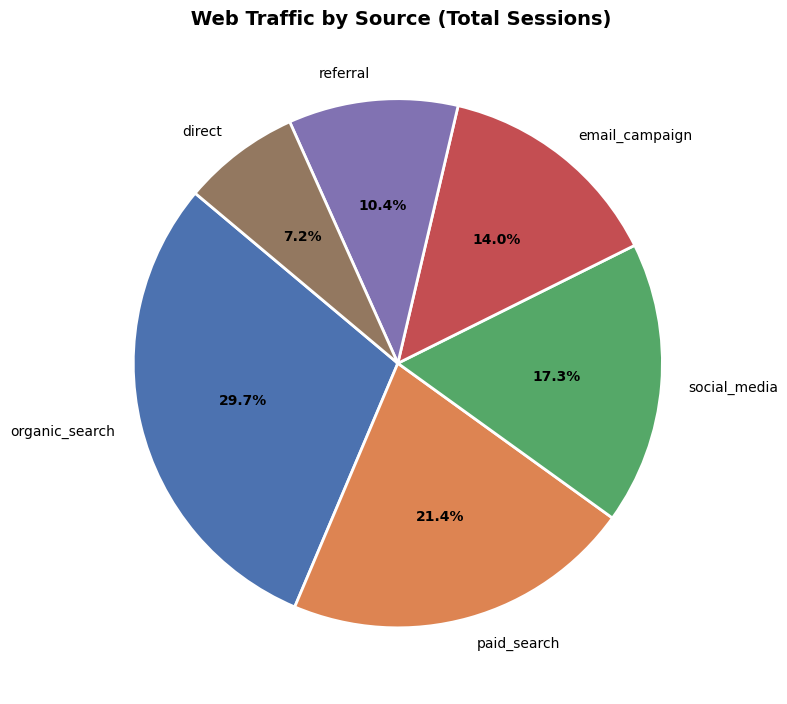

In [8]:
# Chart 6: Traffic Source Distribution
fig, ax = plt.subplots(figsize=(8, 8))

src = web_traffic.groupby('traffic_source')['sessions'].sum().sort_values(ascending=False)
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
wedges, texts, autotexts = ax.pie(
    src.values, labels=src.index, autopct='%1.1f%%',
    colors=colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title(' Web Traffic by Source (Total Sessions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Overview: Biểu đồ tròn thể hiện tỷ trọng tổng sessions theo từng nguồn traffic, giúp so sánh hiệu quả đóng góp của các kênh digital và định hướng phân bổ ngân sách marketing.

Descriptive
Organic search chiếm tỷ trọng lớn nhất (29,7% — 27,2 triệu sessions), tiếp theo là paid search (21,4% — 19,6 triệu), social media (17,3% — 15,8 triệu). Direct thấp nhất chỉ 7,2% (6,6 triệu sessions). Tổng cộng ~91,5 triệu sessions trong toàn giai đoạn khảo sát.
Diagnostic
Organic search dẫn đầu cả về lượng khách hàng (Chart 1) lẫn sessions — SEO là lợi thế cạnh tranh cốt lõi nhất quán. Paid search chiếm 21,4% sessions nhưng chỉ đóng góp 19,9% khách hàng — hiệu suất chuyển đổi thấp hơn organic, gợi ý CAC của kênh này cao hơn. Email campaign chỉ có 13,9% sessions nhưng session duration cao nhất (213s) — kênh nhỏ nhưng chất lượng cao nhất.
Predictive — What is likely to happen?
Chi phí paid search đang tăng toàn ngành — nếu không tối ưu, ROI của kênh này sẽ tiếp tục giảm. Referral (10,4%) hiện chưa được khai thác — với chương trình đúng, kênh này có thể tăng gấp đôi mà chi phí thấp hơn paid search nhiều lần.
Prescriptive
Tái cân bằng ngân sách: giảm tỷ trọng paid search (CAC cao), tăng đầu tư vào email (chất lượng cao nhất) và referral (tiềm năng cao, chi phí thấp).
Xây dựng referral program chính thức: mục tiêu đưa referral từ 10,4% lên 15–18% trong 12 tháng thông qua incentive cho cả hai phía.
Kết nối dữ liệu sessions với đơn hàng để đo ROI thực sự của từng kênh — biết kênh nào convert tốt nhất mới phân bổ ngân sách chính xác được.